In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tessreduce as tr
%matplotlib notebook

made reference
!!!WARNING!!! mask is too dense, lowering mask_scale to 0.5, and raising maglim to 15. Background quality will be reduced.
made source mask
calculating background
background subtracted
aligning images
!!Re-running for difference image!!
shifting images
remade mask
background
background correlation correction


<IPython.core.display.Javascript object>


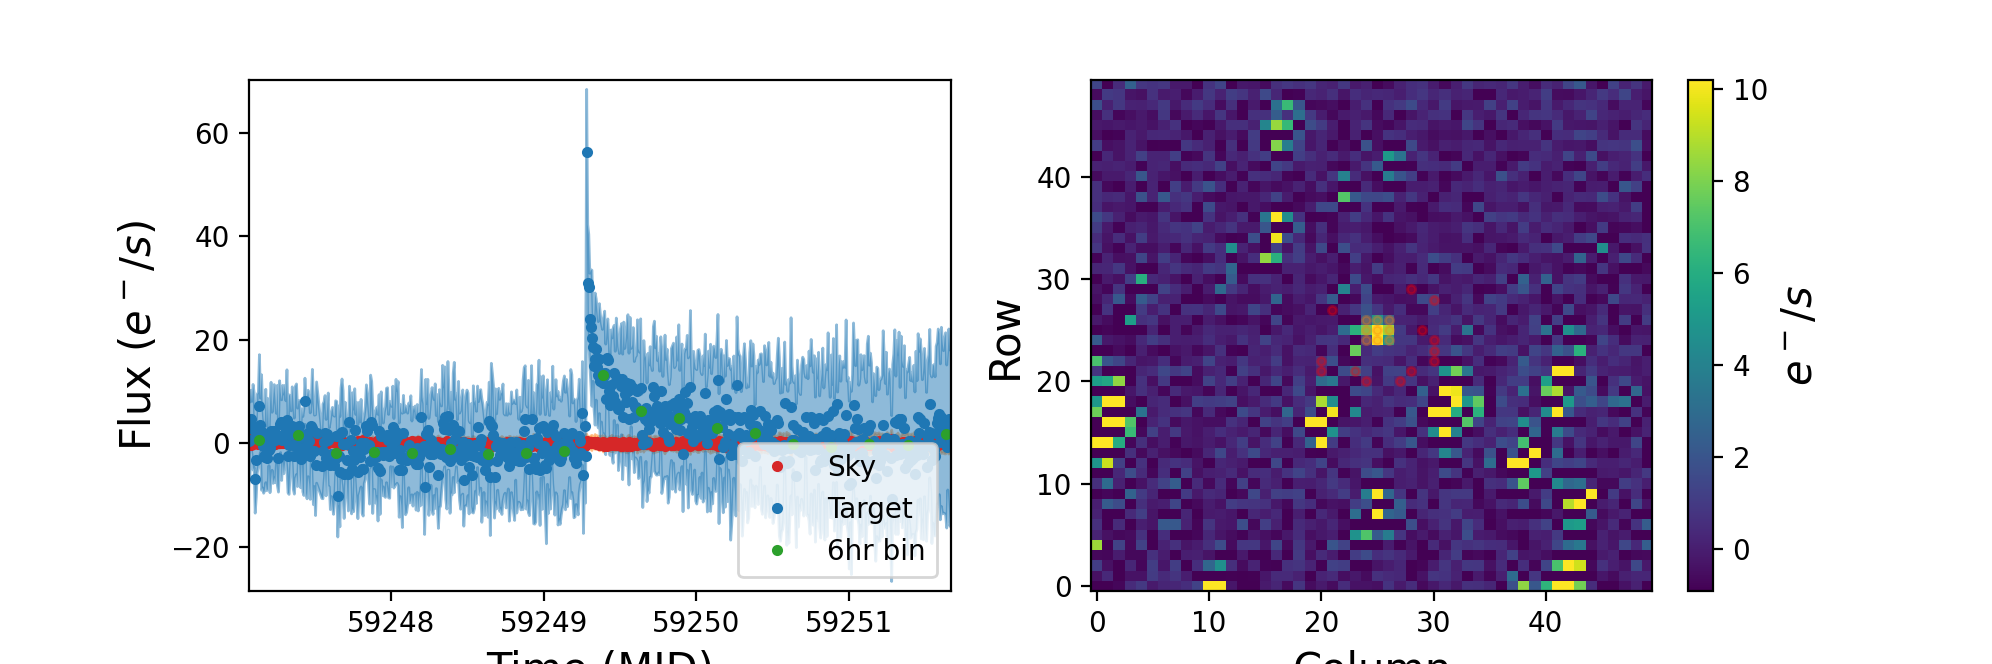

In [2]:
tess = tr.tessreduce(tpf='../../SN_individual/grb_test.fits',calibrate=False,diff=True)

In [4]:
tr.sigma_clipped_stats(tess.lc[1])

(0.5074744185183834, 0.4845421995512588, 2.9524085215662574)

Optimal PSF shift:  [-0.79997333 -0.8       ]


<IPython.core.display.Javascript object>


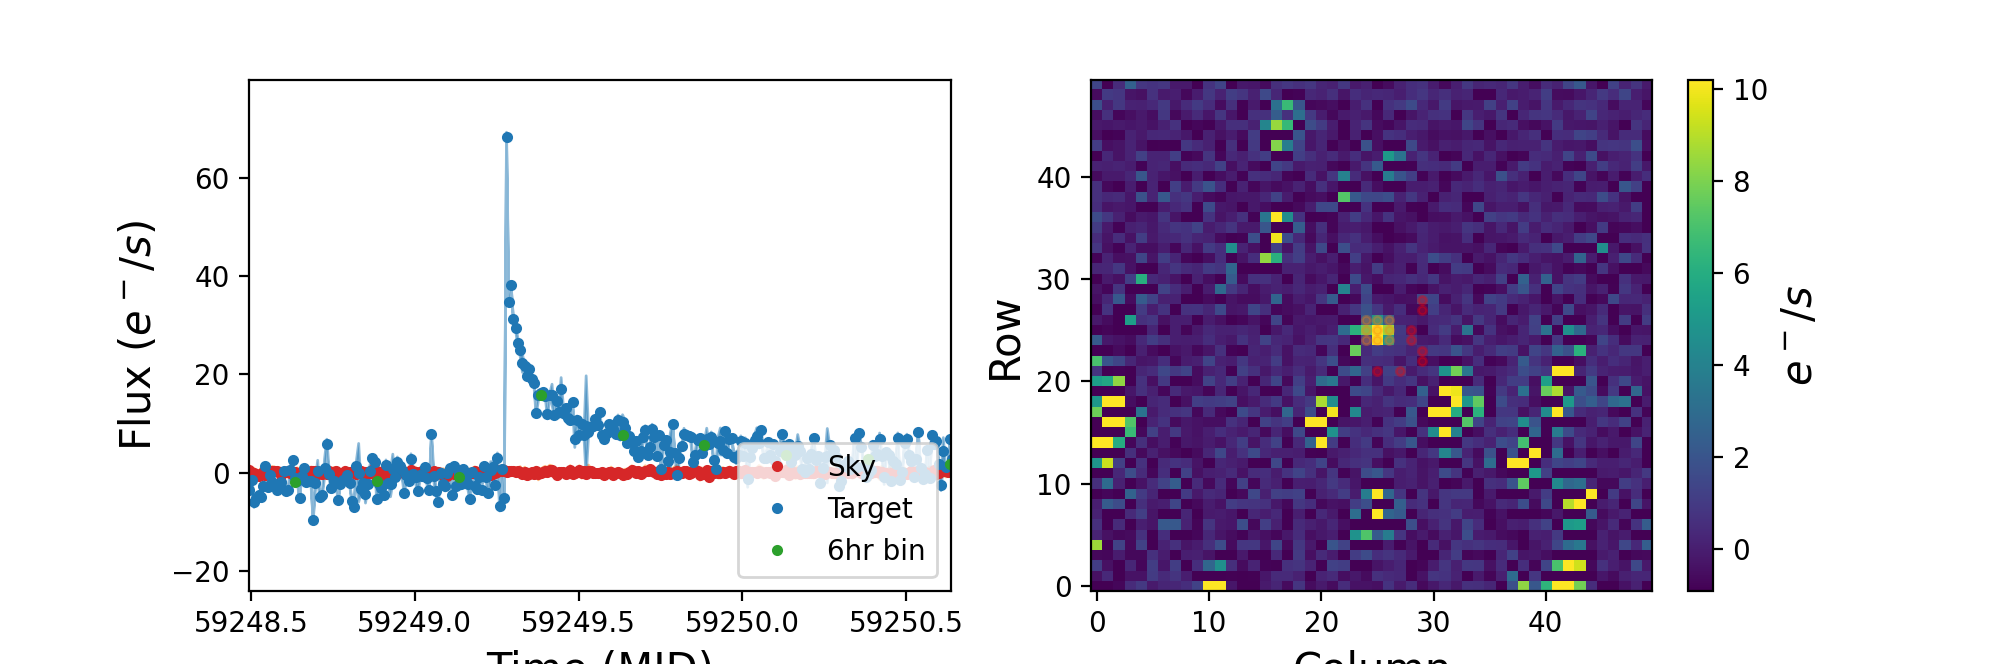

In [3]:
l = tess.diff_lc(phot_method='psf',plot=True)

In [5]:
tr.sigma_clipped_stats(l[0][1])

(0.39491730756917903, 0.2551290720986874, 3.1624806280483053)

In [20]:
tess.flux = tr.strip_units(tess.tpf.flux)
tess.flux = tess.flux / tess.qe

if tess.align:
    tess.shift_images()

In [21]:
ref = tess.flux[tess.ref_ind]

<IPython.core.display.Javascript object>


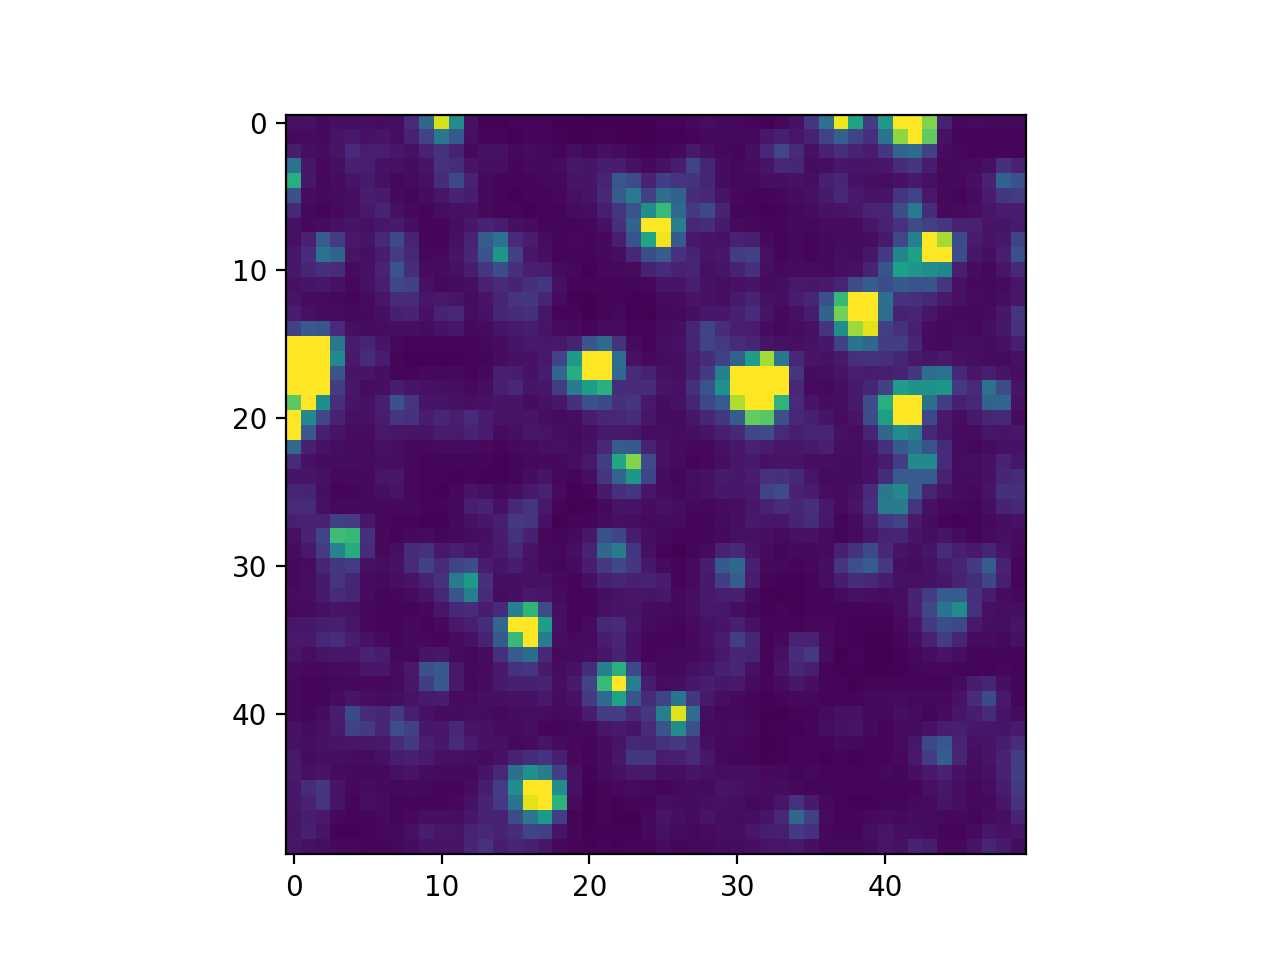

In [25]:
plt.figure()
plt.imshow(ref,vmax=500)

In [26]:
bright = np.nansum(tess.flux,axis=(1,2))

In [62]:
m,med,std = tr.sigma_clipped_stats(tess.flux,axis=(1,2))
sm, smed, sstd = tr.sigma_clipped_stats(std)
ind = np.where((std < (smed + 3*sstd)) & (std > (smed - 3*sstd)))[0]
stack = np.nanmedian(tess.flux[ind],axis=0)

In [63]:
tr.sigma_clipped_stats(ref)

(135.18896629751455, 130.50159287107397, 15.036304144564637)

In [64]:
tr.sigma_clipped_stats(stack)

(143.4577684244843, 138.9558073961959, 14.922821471446785)

<IPython.core.display.Javascript object>


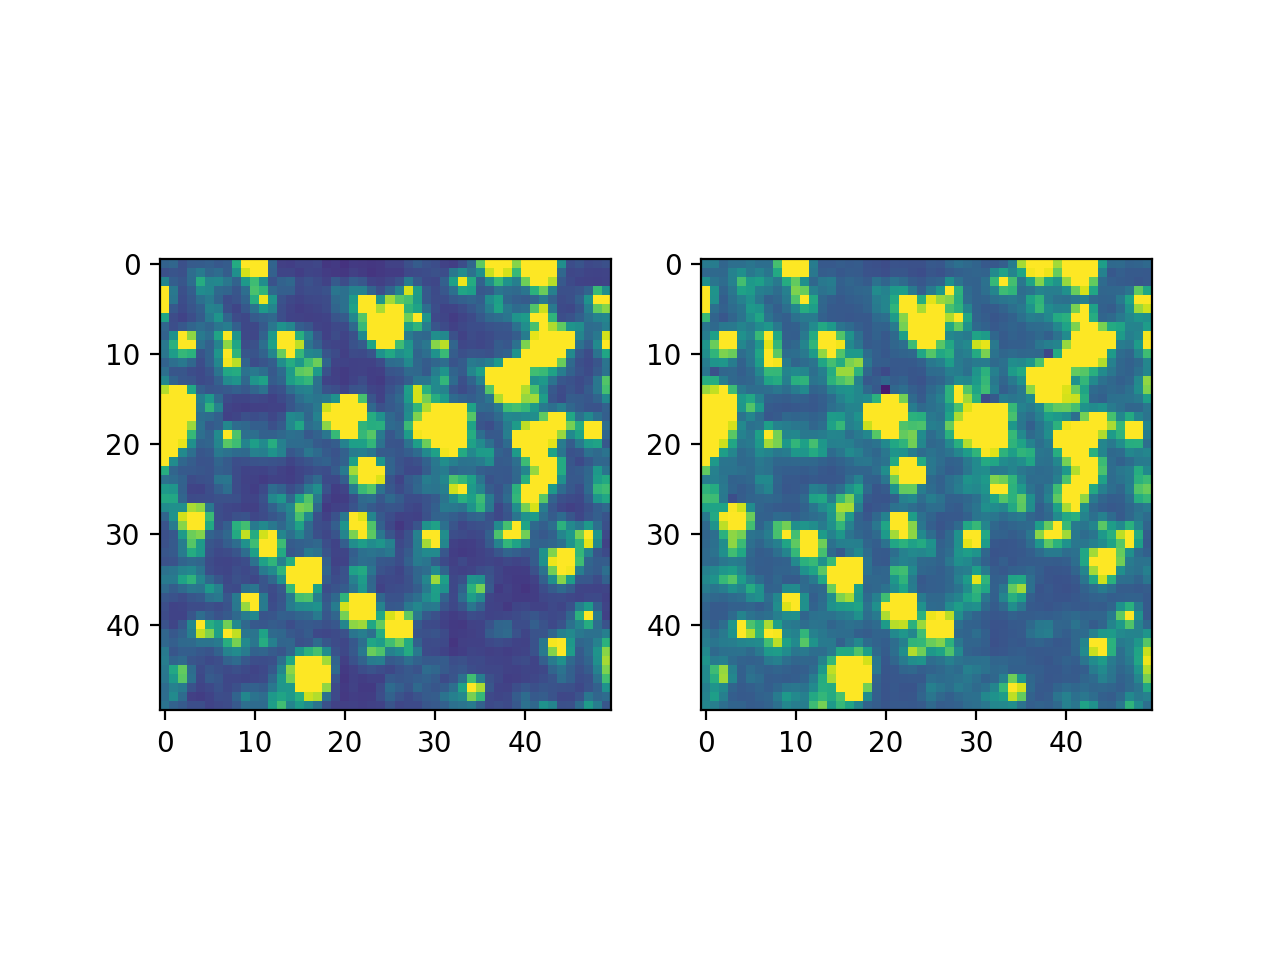

In [65]:
plt.figure()
plt.subplot(121)
plt.imshow(ref,vmax=200,vmin=100)
plt.subplot(122)
plt.imshow(stack,vmax=200,vmin=100)

In [74]:
np.median(d2)

-7.128225745011747

<IPython.core.display.Javascript object>


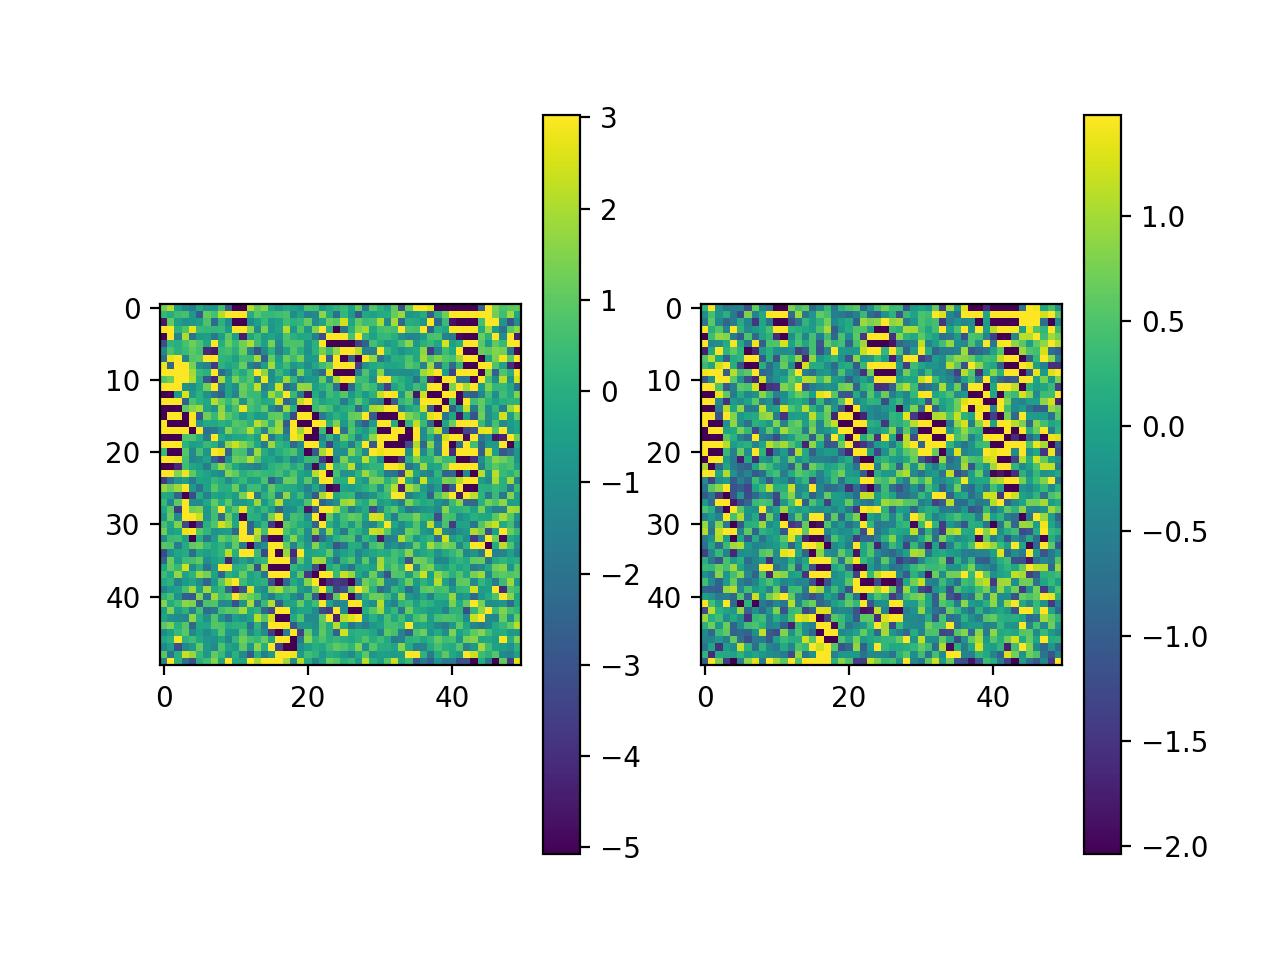

In [80]:
d1 = tess.flux[100] - ref
d2 = tess.flux[100] - stack
d2 -= np.median(d2)
d1 -= np.median(d1)
plt.figure()
plt.subplot(121)
plt.imshow(d1,vmin=np.nanpercentile(d1,5),vmax=np.percentile(d1,90))#,vmax=200,vmin=100)
plt.colorbar()
plt.subplot(122)
plt.imshow(d2,vmin=np.nanpercentile(d2,5),vmax=np.percentile(d2,90))#,vmax=200,vmin=100)
plt.colorbar()

In [81]:
tr.sigma_clipped_stats(d1)

(0.0176669473270038, -0.0159029262837862, 1.7082819811977064)

In [82]:
np.sum(d2)

217.53101395971555

In [83]:
np.sum(d1)

397.4053733660529

In [84]:
tr.sigma_clipped_stats(d2)

(0.017184440942750786, -0.006614898391653412, 0.9010009546158947)

<IPython.core.display.Javascript object>


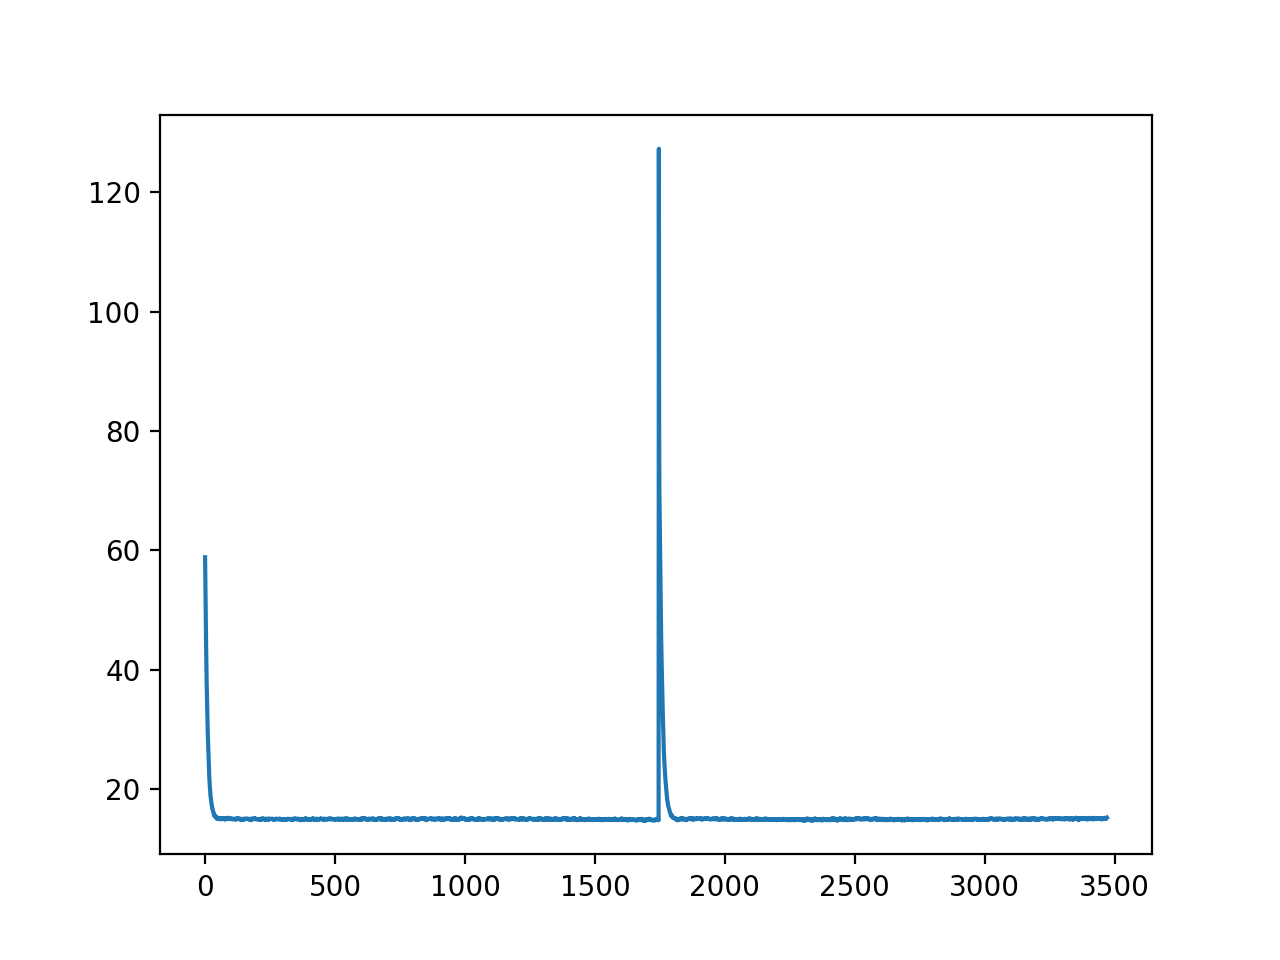

In [33]:
plt.figure()
plt.plot(std)

<IPython.core.display.Javascript object>


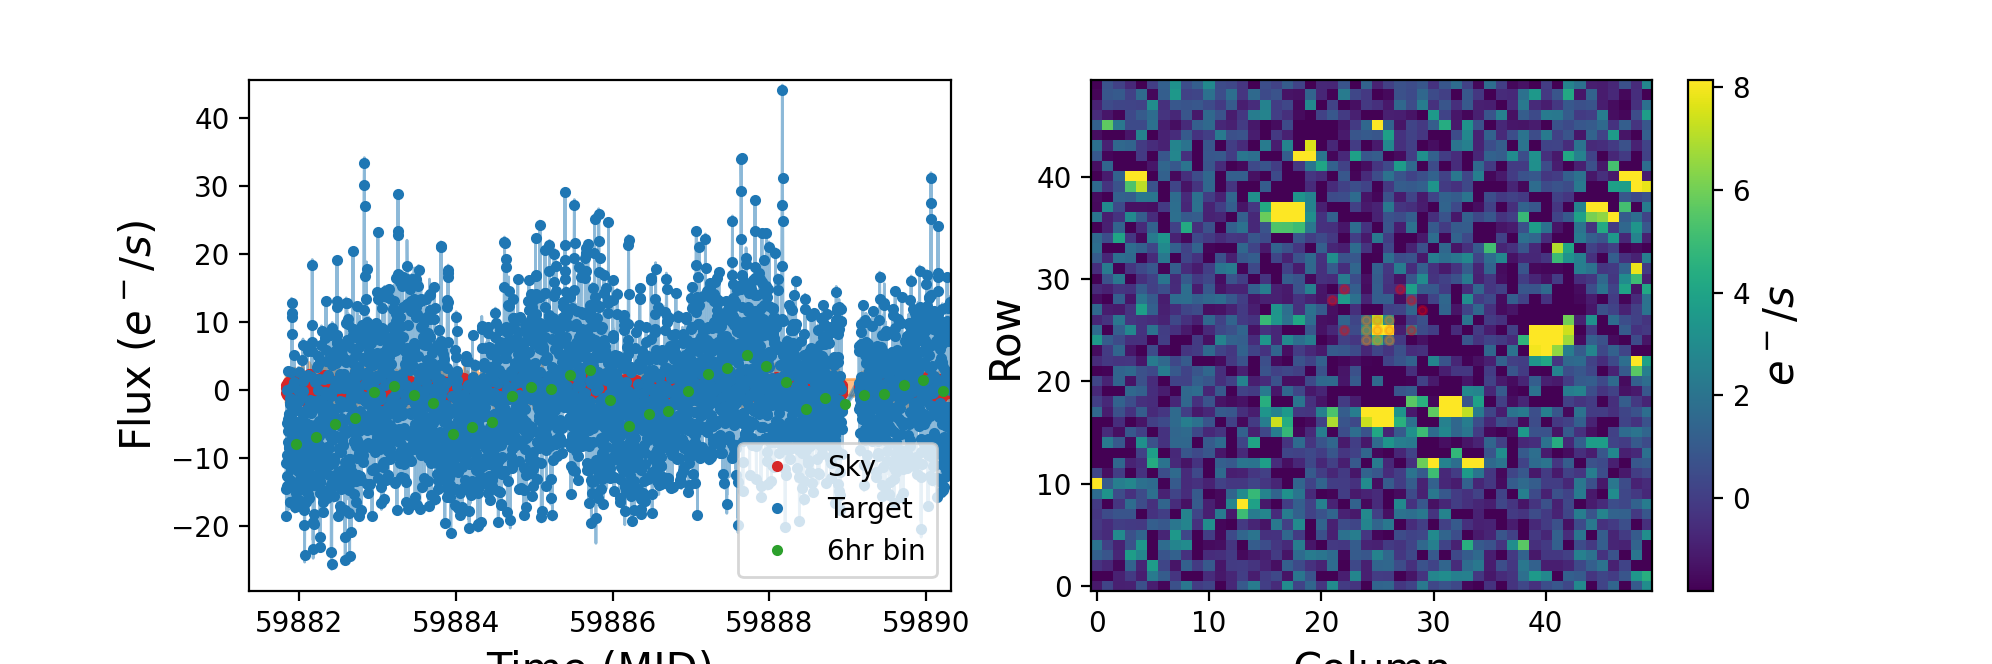

(array([[ 5.98818366e+04,  5.98818389e+04,  5.98818413e+04, ...,
          5.99095469e+04,  5.99095492e+04,  5.99095515e+04],
        [-1.07113961e+01, -1.46373448e+01, -1.85746908e+01, ...,
         -2.95190204e+00, -8.43048290e+00, -1.35432273e+01],
        [ 3.20643640e-01,  1.81864970e-01,  1.58968489e-01, ...,
          2.36887899e-01,  1.33115664e+01,  2.57972995e-01]]),
 array([[ 5.98818366e+04,  5.98818389e+04,  5.98818413e+04, ...,
          5.99095469e+04,  5.99095492e+04,  5.99095515e+04],
        [ 2.52676986e-01,  6.37262803e-01, -4.82652514e-01, ...,
          1.12220358e+00,  3.91216858e-01,  4.22198838e-01],
        [ 2.20838380e+00,  2.30175807e+00,  1.54319803e+00, ...,
          9.31596251e-01,  7.92200556e-01,  9.16807684e-01]]))

In [11]:
tess.diff_lc(phot_method='psf',plot=True)

In [12]:
import power_scan as ps

In [14]:
tess.mjd

array([59881.83663189, 59881.83894672, 59881.84126155, ...,
       59909.54690211, 59909.54921685, 59909.55153158])

In [15]:
power = ps.periodogram_detection(tess.mjd,tess.flux)

making cube
(11692,)
finding sources
cleaning detections
finding peak frequency
finding fundamental period


<IPython.core.display.Javascript object>


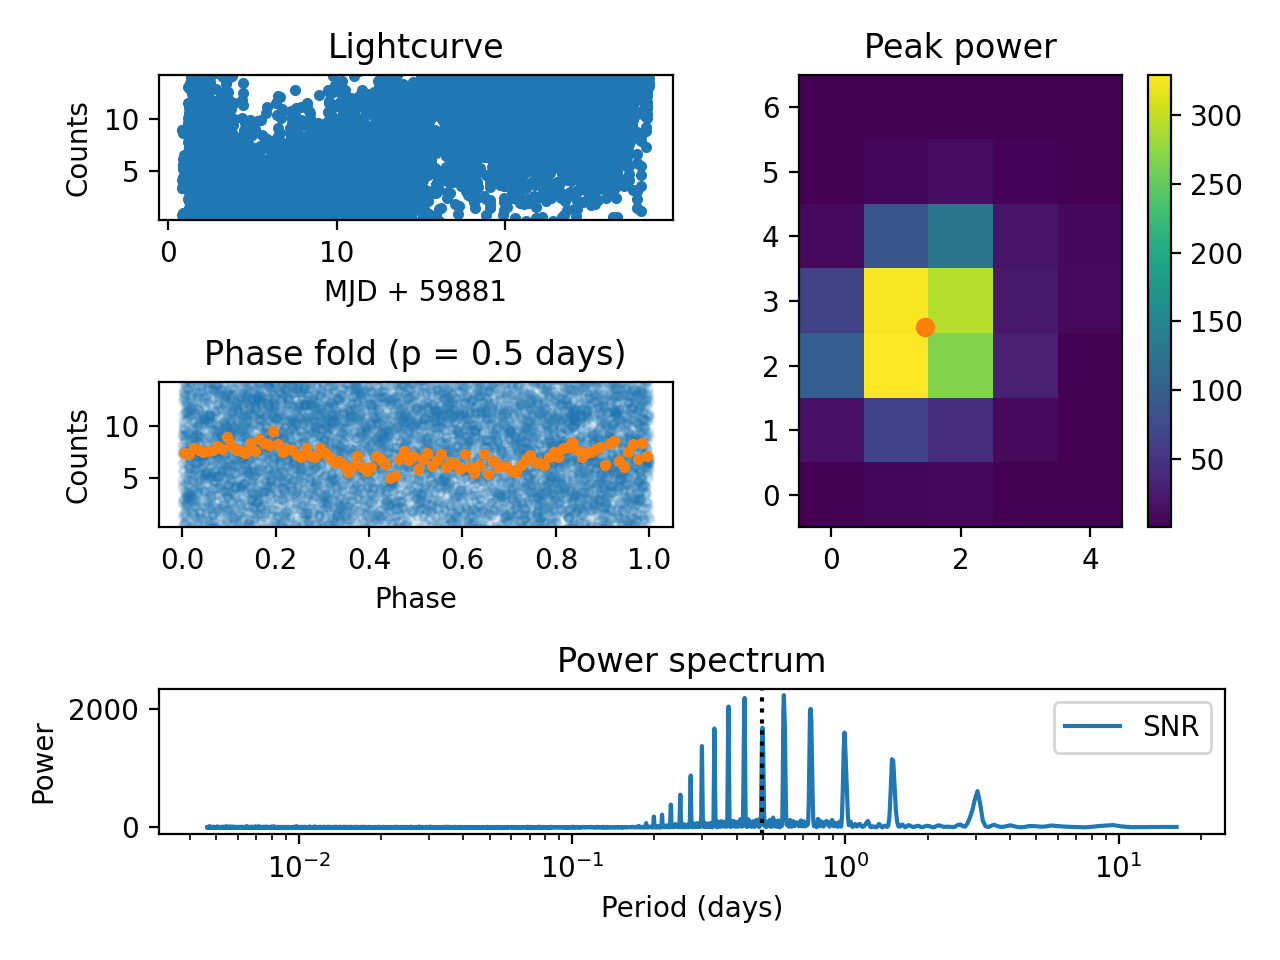

<IPython.core.display.Javascript object>


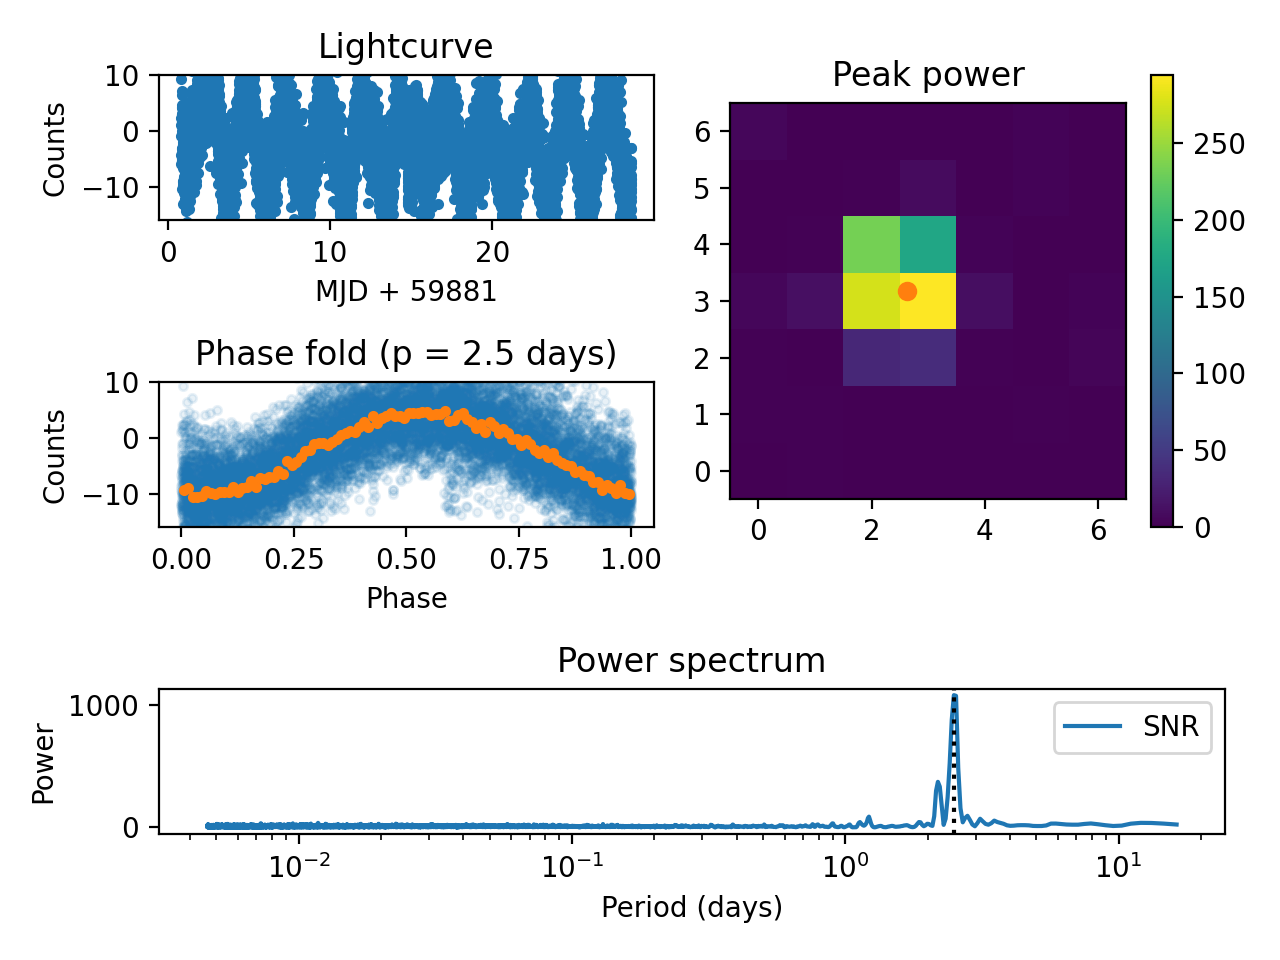

<IPython.core.display.Javascript object>


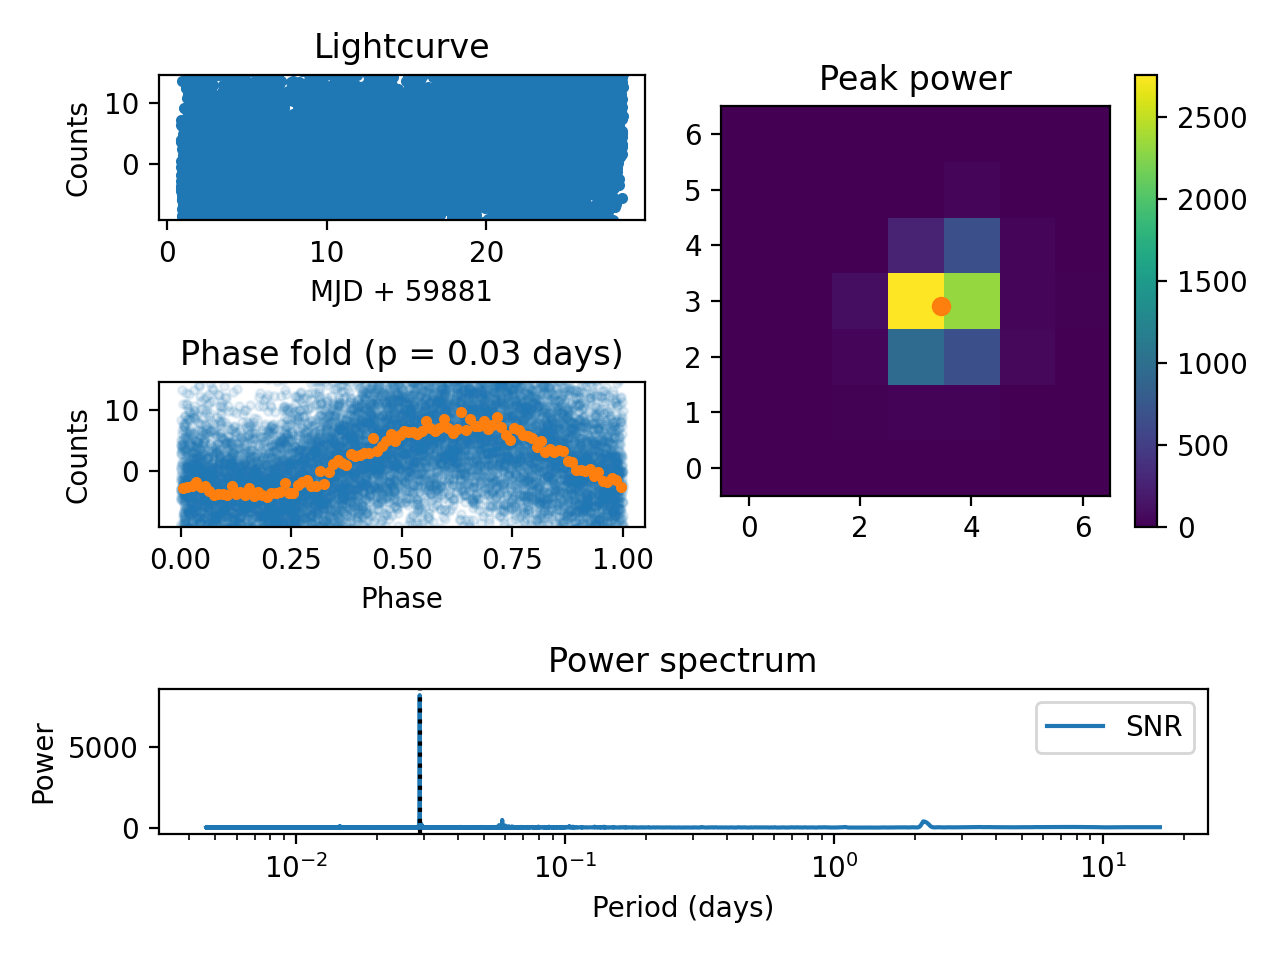

<IPython.core.display.Javascript object>


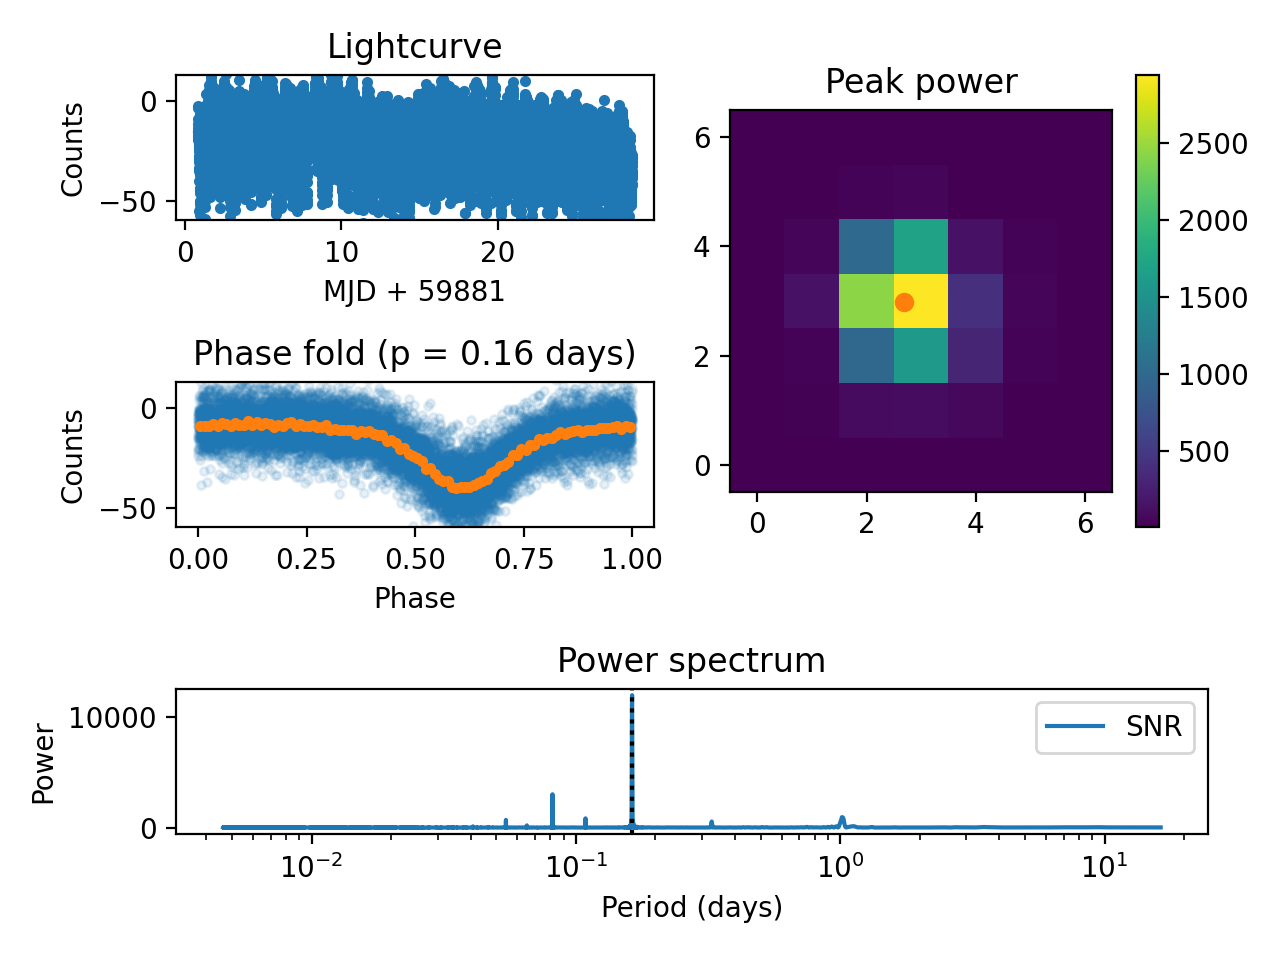

<IPython.core.display.Javascript object>


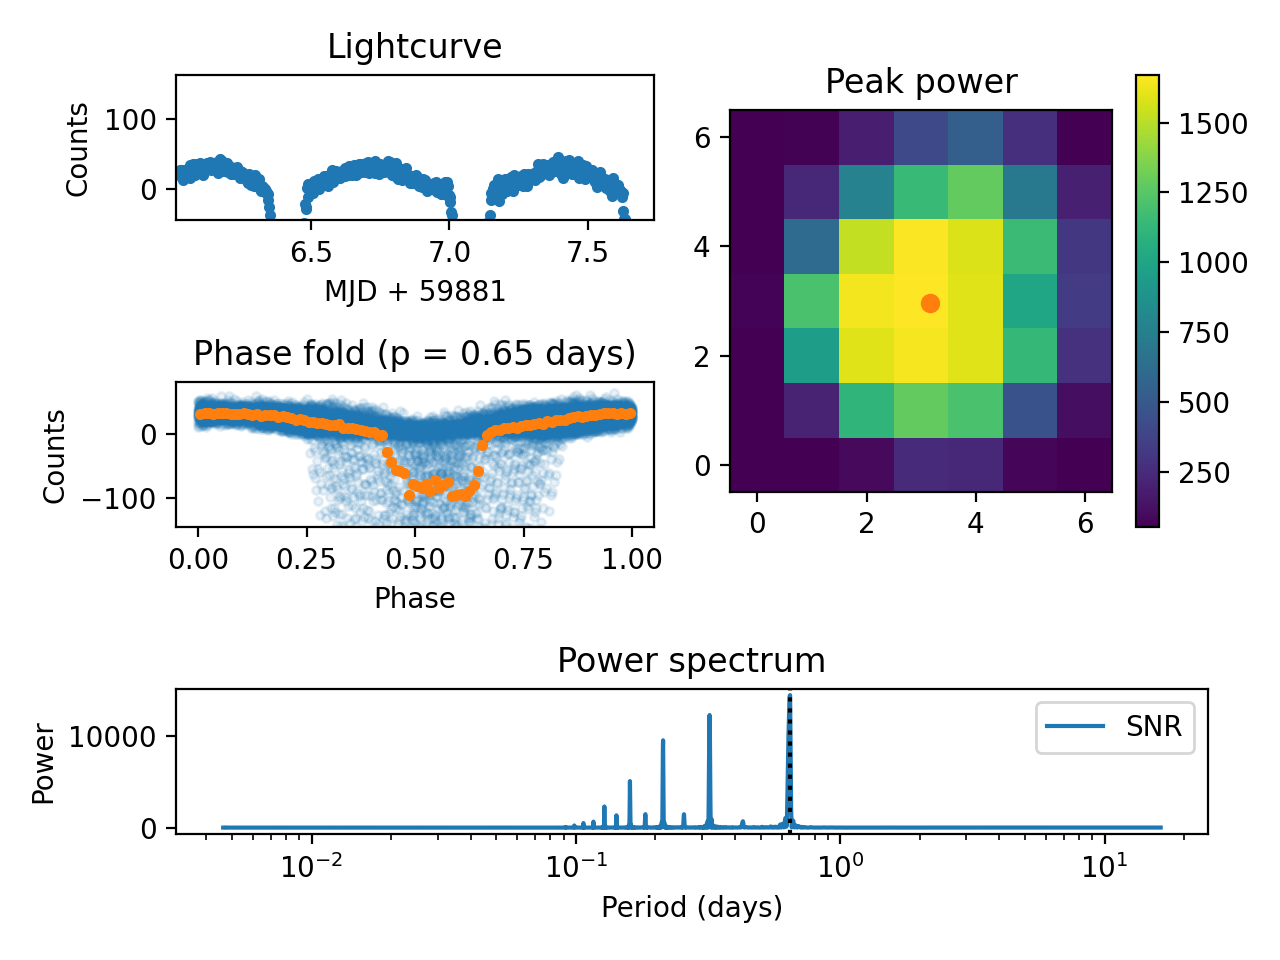

<IPython.core.display.Javascript object>


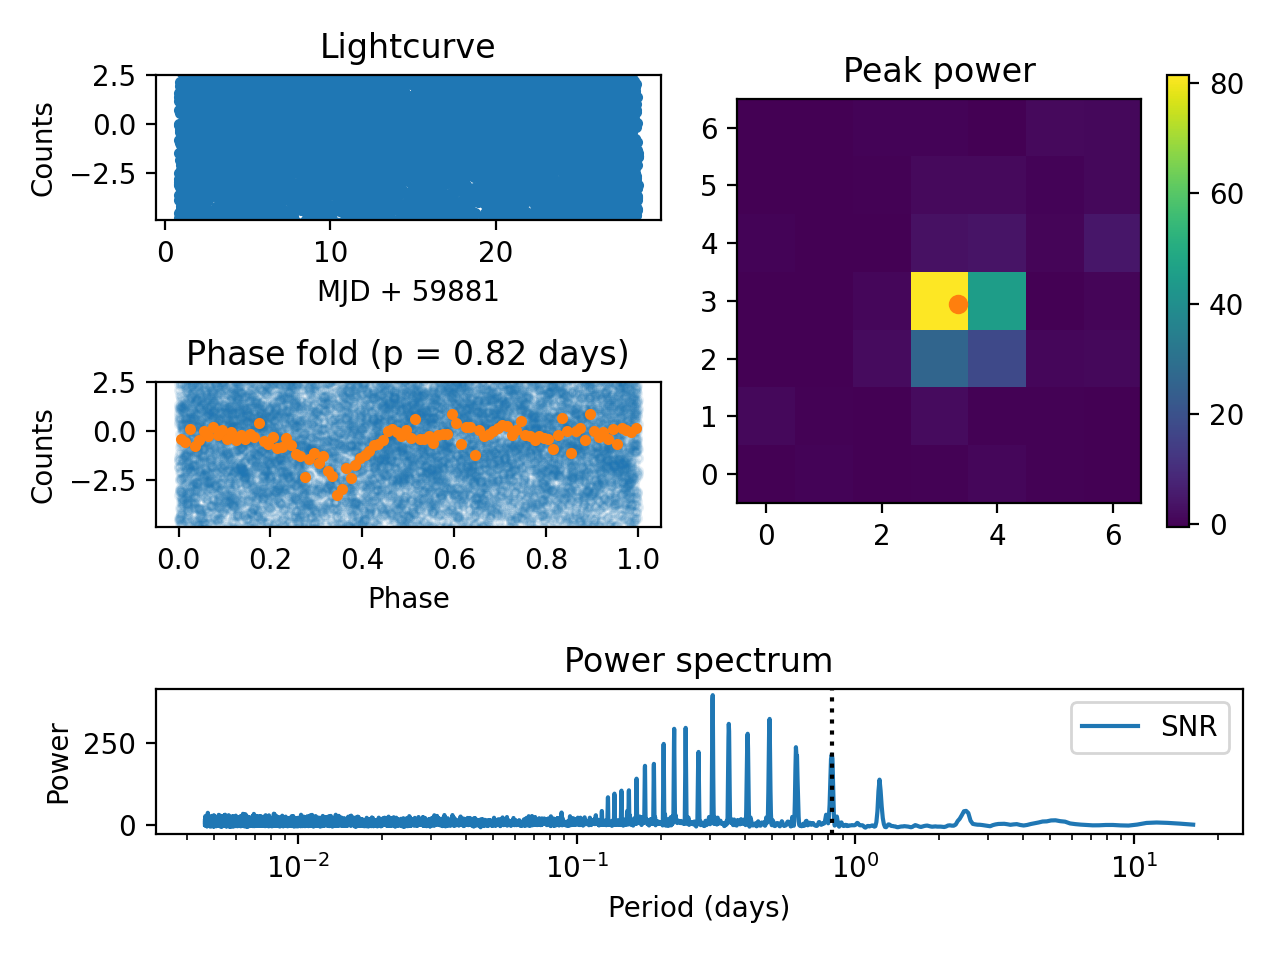

<IPython.core.display.Javascript object>


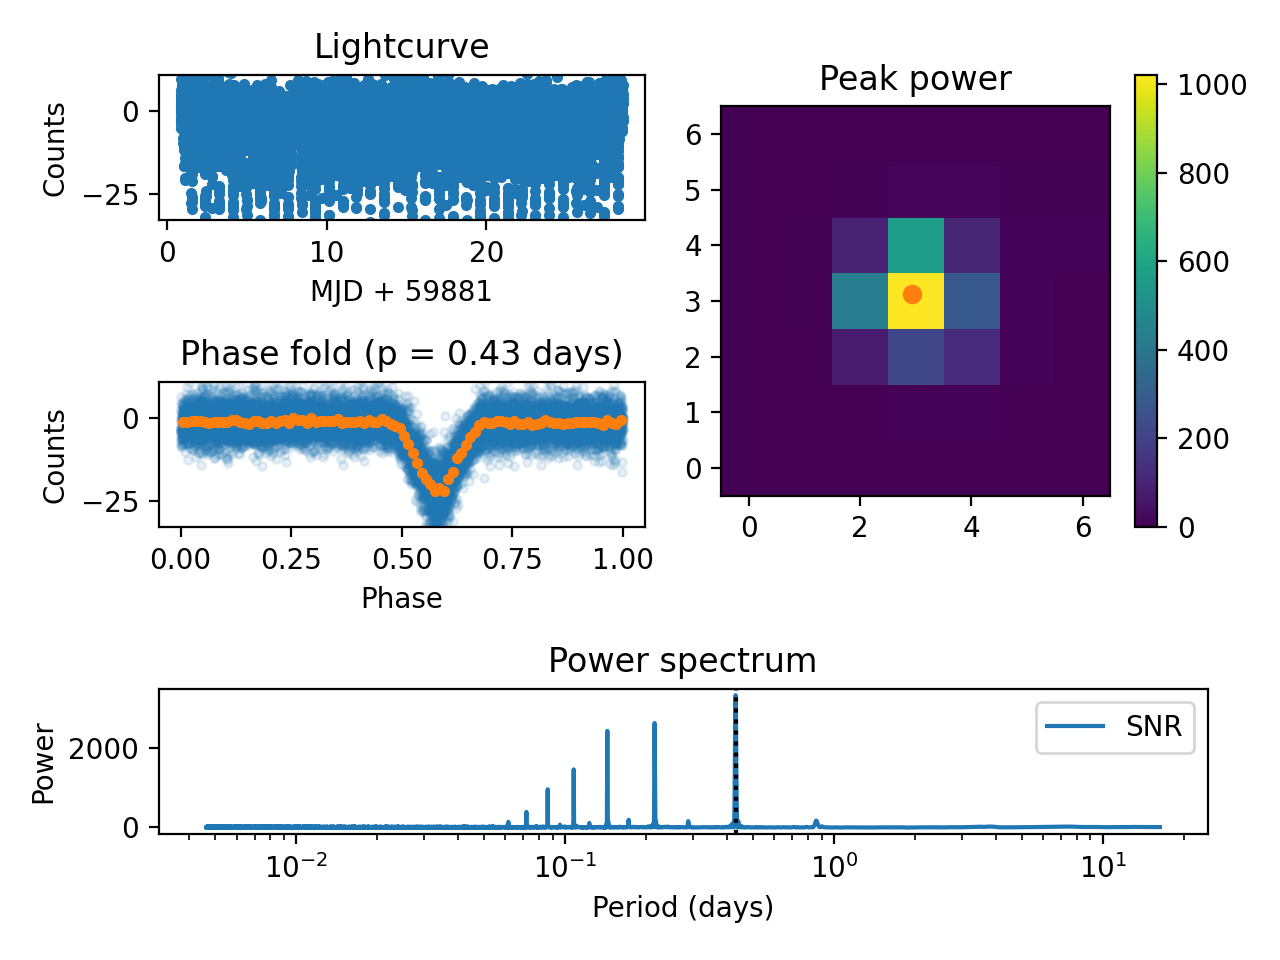

<IPython.core.display.Javascript object>


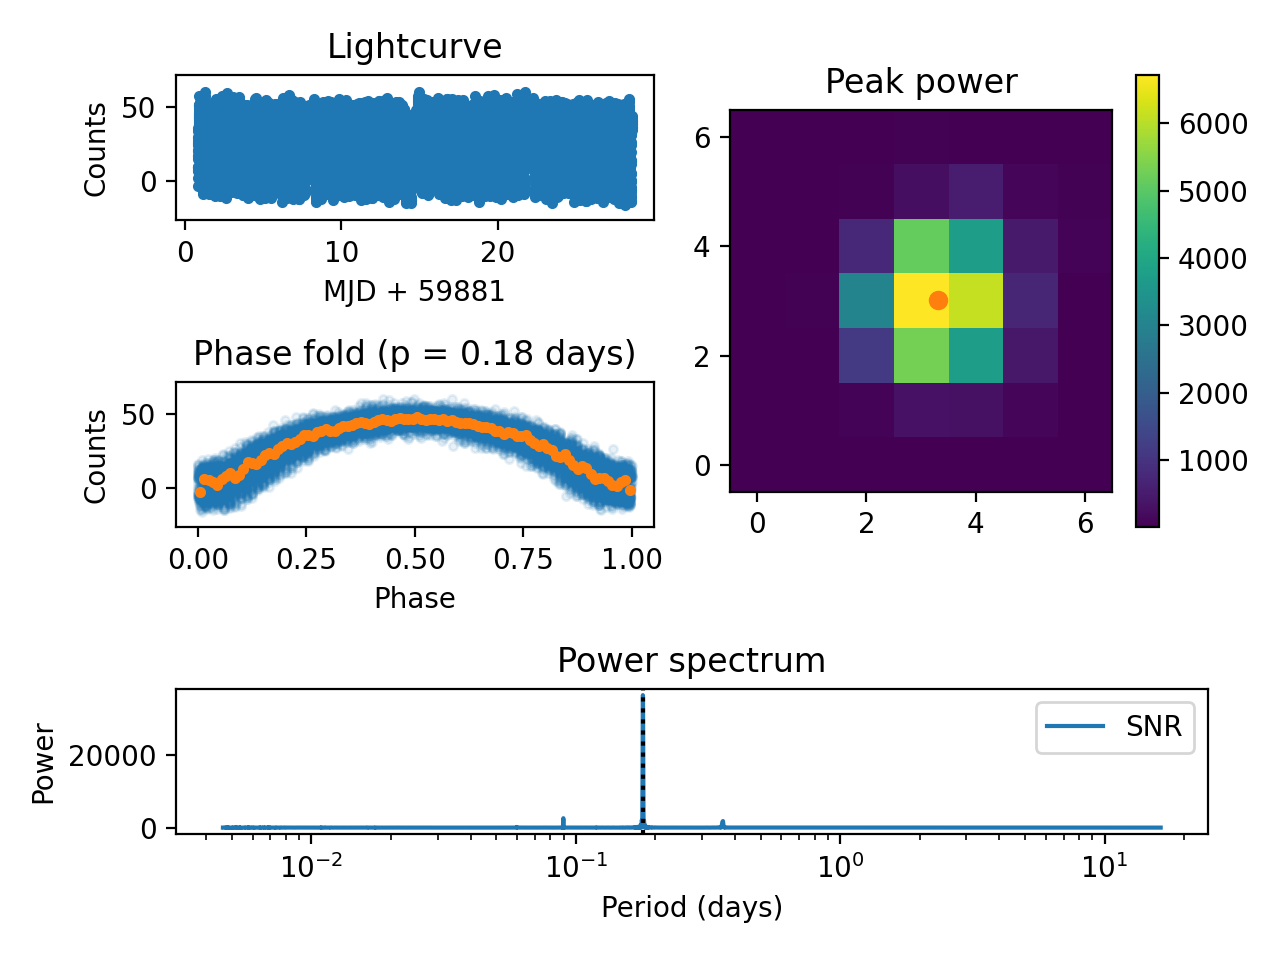

<IPython.core.display.Javascript object>


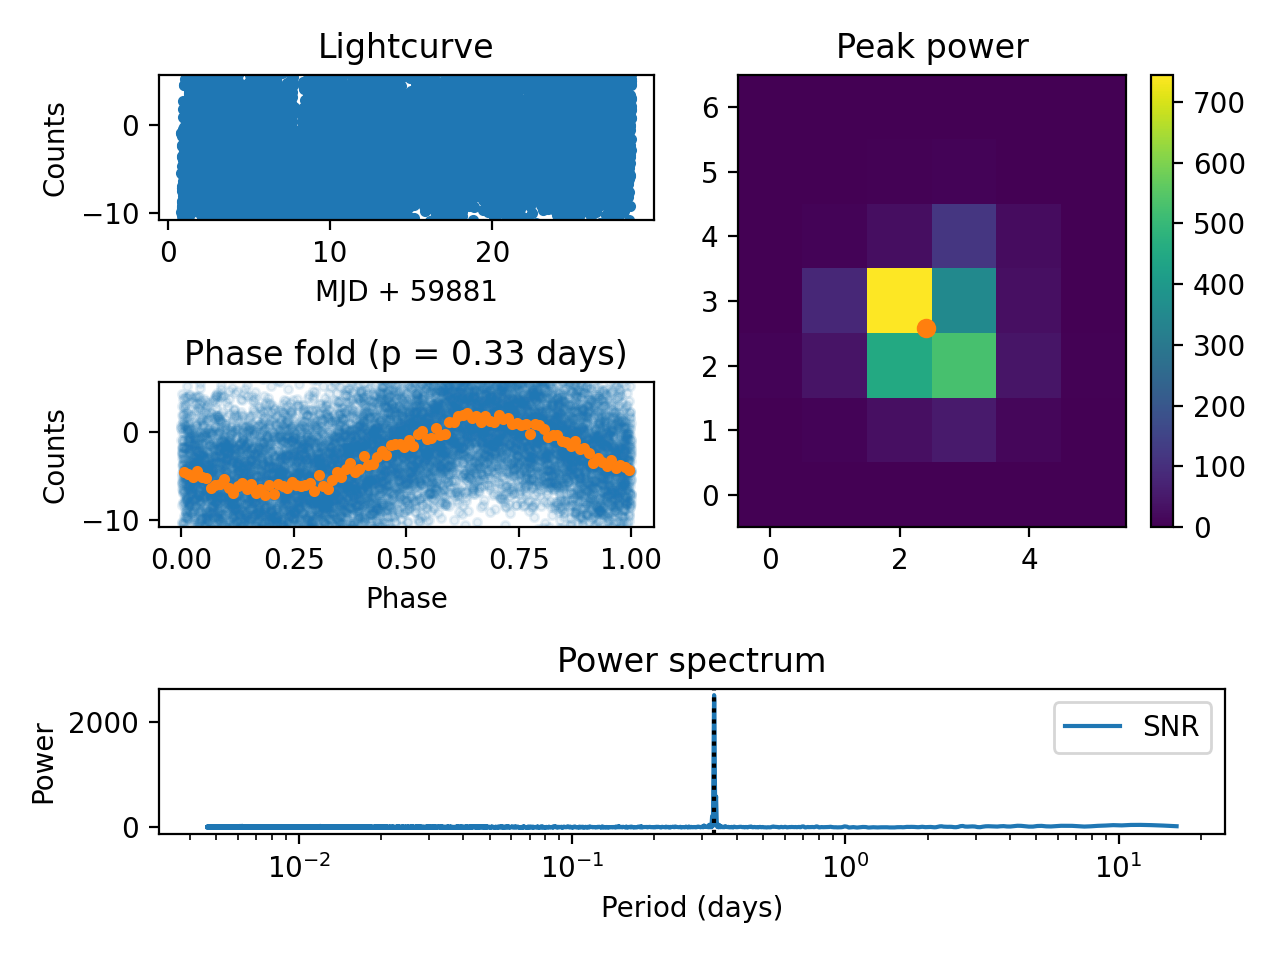

<IPython.core.display.Javascript object>


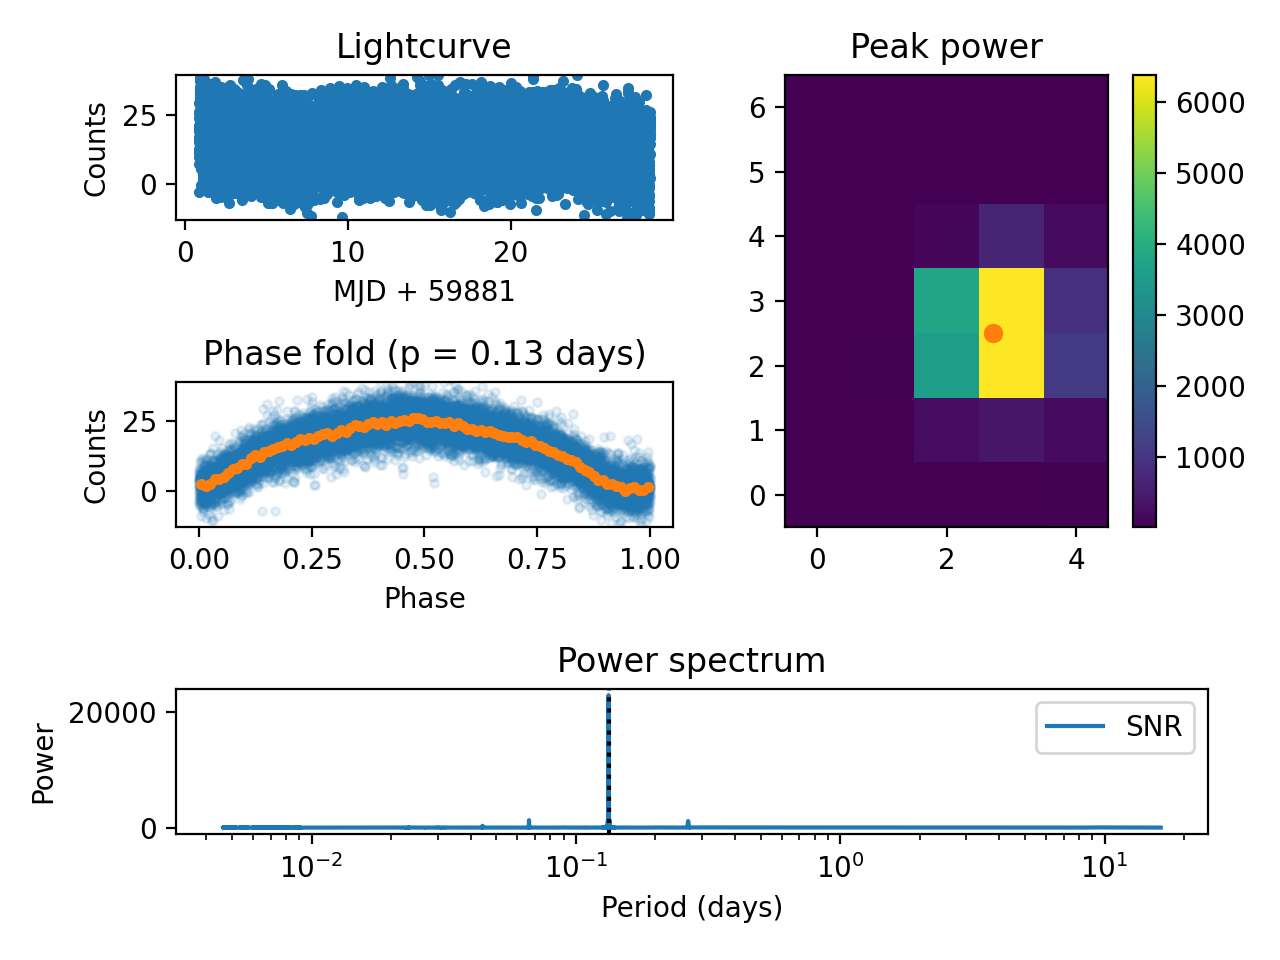

<IPython.core.display.Javascript object>


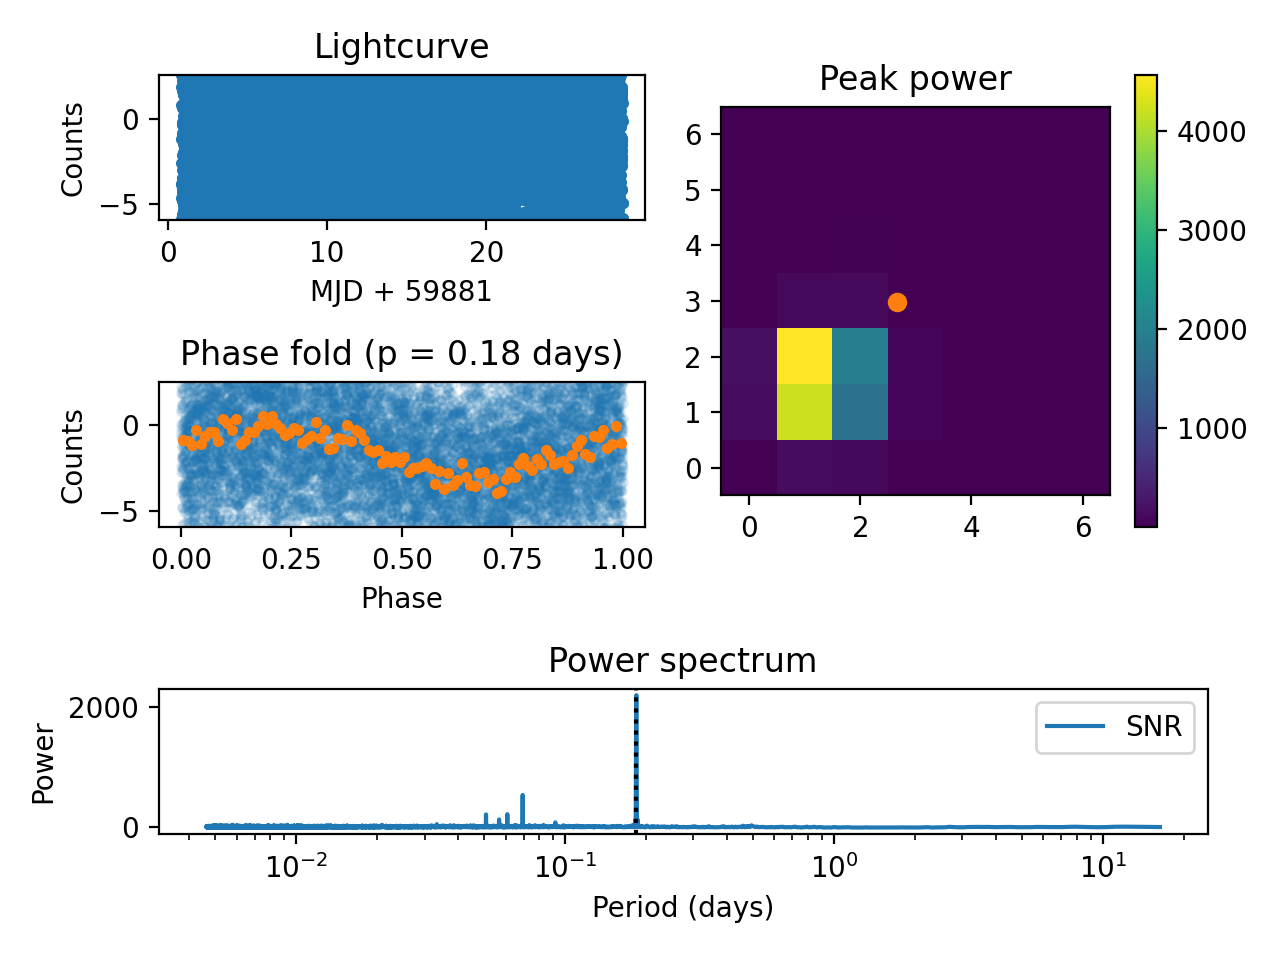

<IPython.core.display.Javascript object>


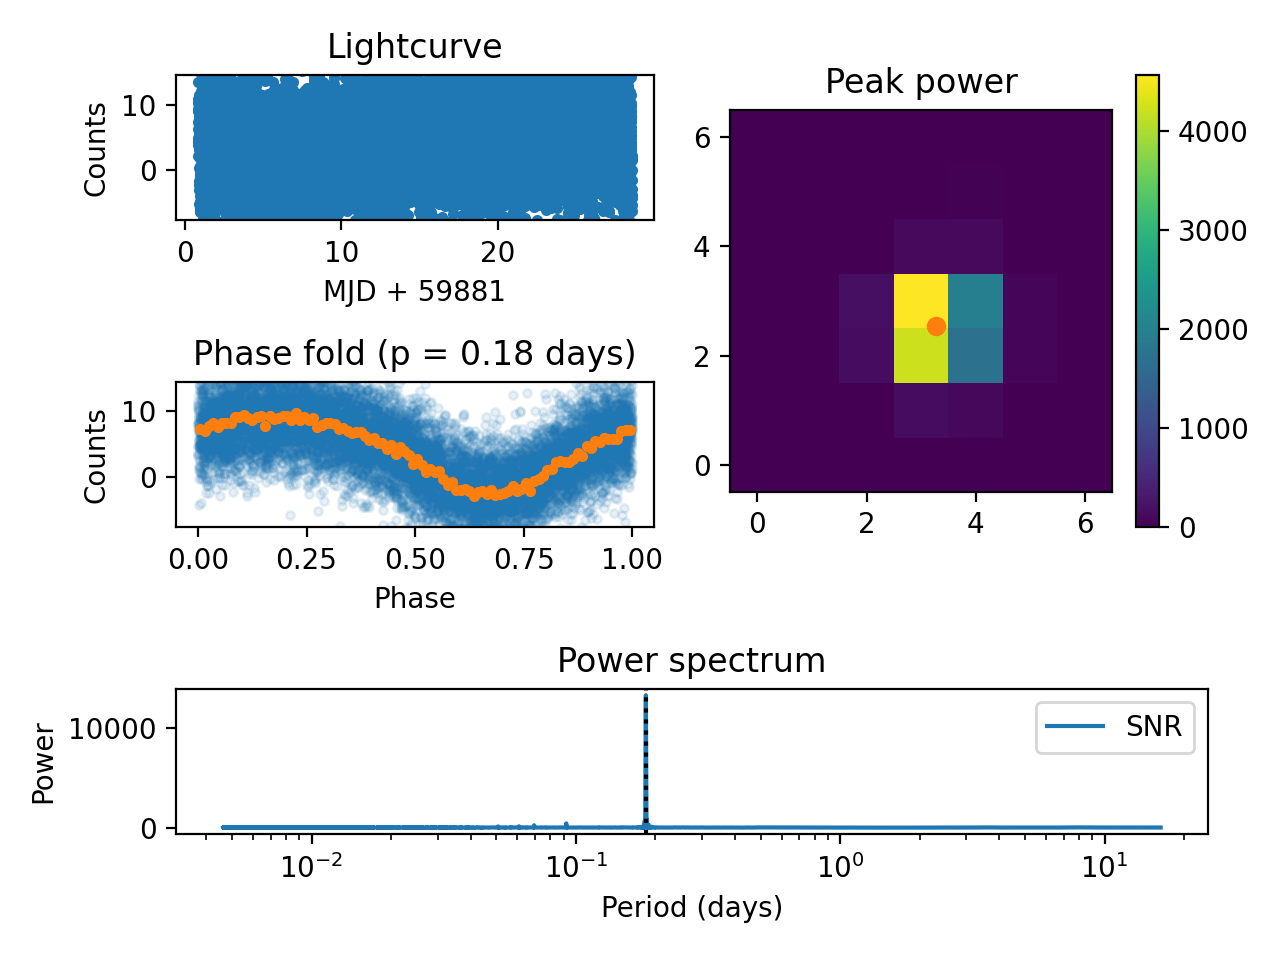

<IPython.core.display.Javascript object>


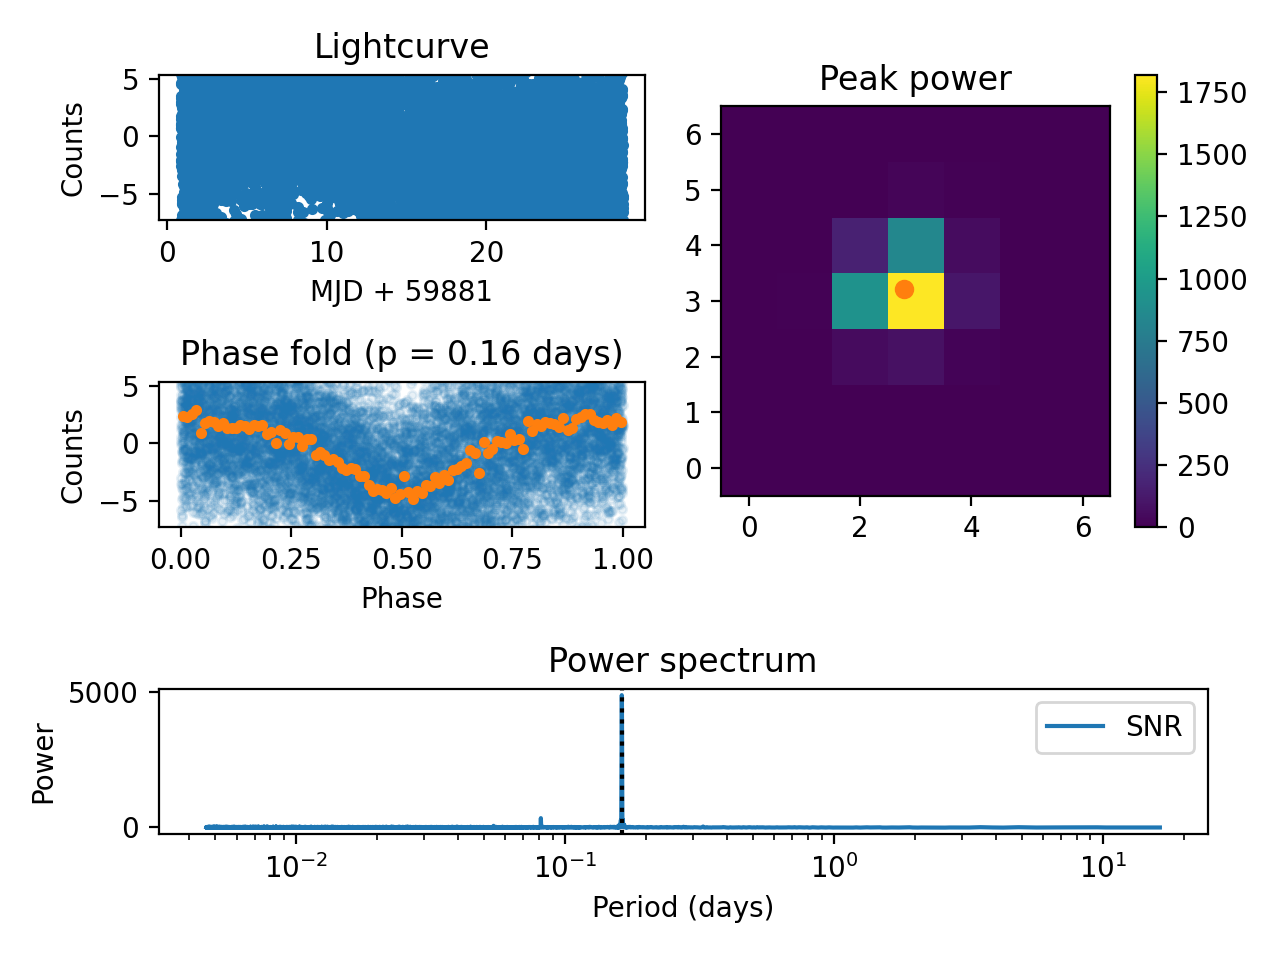

In [18]:
power.plot_object()

<IPython.core.display.Javascript object>


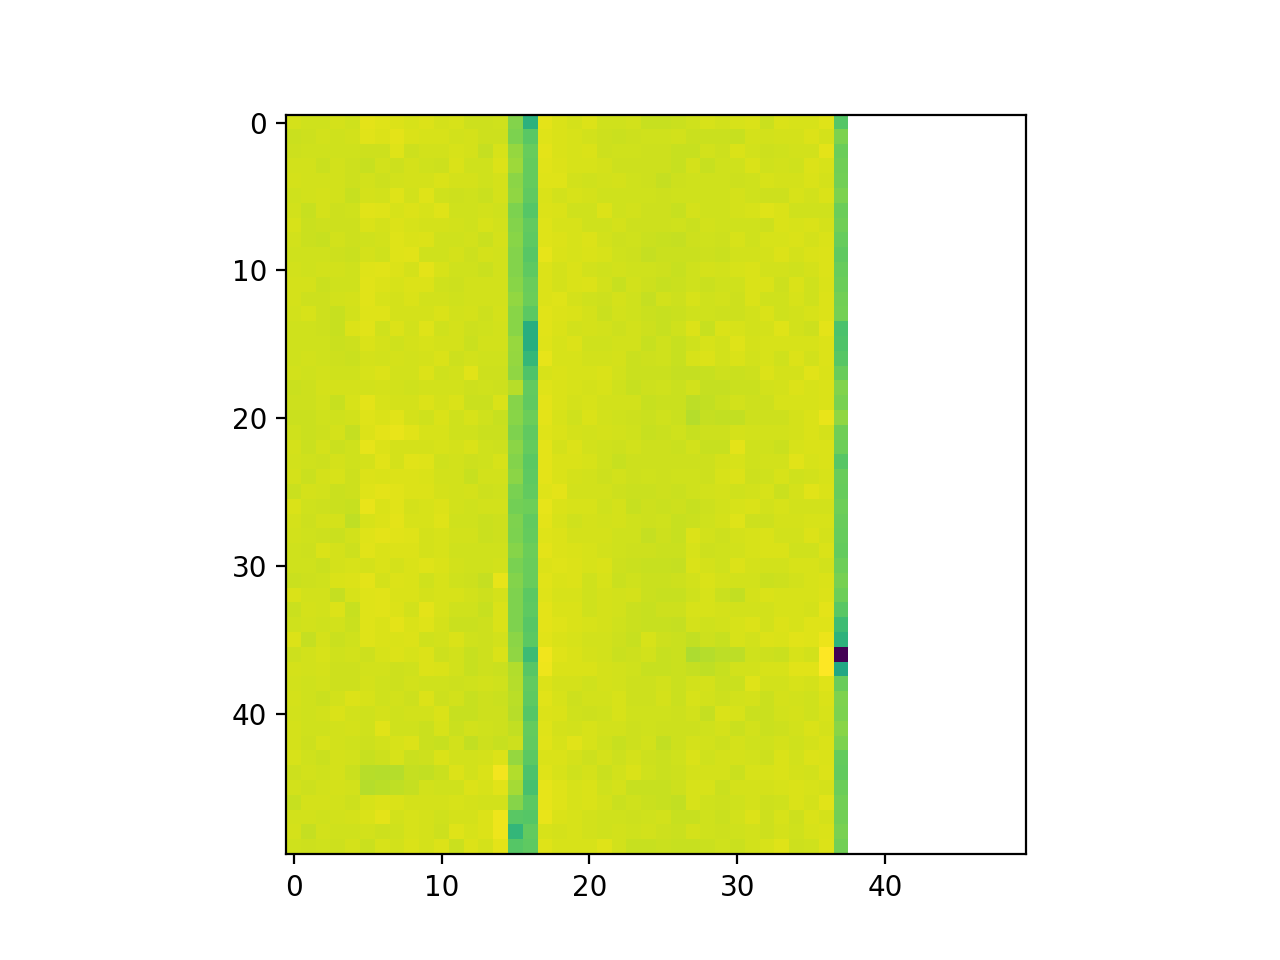

In [9]:
plt.figure()
plt.imshow(np.nanmean(tess.tpf.flux.value,axis=0))